In [ ]:
import pandas as pd
import numpy as np
import glob
from datetime import datetime
from pathlib import Path
import os
from collections import defaultdict
from scipy.stats import skew
from scipy.stats import kurtosis
from numpy.fft import fft, fftfreq
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV


## NASA Bearing Dataset

Description of data: At the end of the test-to-failure experiment, outer race failure occurred in bearing 1.
Our target response variable will be Root Mean Square (RMS) for bearing 1(channel 1), since this is where the failure occured

In [122]:
files = glob.glob('data/NASA_bearing_datasest/3rd_test/4th_test/txt/*')
print(len(files))  # should print 984
print(files[:3]) 

6324
['data/NASA_bearing_datasest/3rd_test/4th_test/txt\\2004.03.04.09.27.46', 'data/NASA_bearing_datasest/3rd_test/4th_test/txt\\2004.03.04.09.32.46', 'data/NASA_bearing_datasest/3rd_test/4th_test/txt\\2004.03.04.09.42.46']


In [123]:
def parse_time(filepath):
    filename = os.path.basename(filepath)
    timestamp = datetime.strptime(filename, '%Y.%m.%d.%H.%M.%S')
    return timestamp

In [124]:
def calc_stats(channel_data):
    rms = np.sqrt(np.mean(channel_data**2))
    peak = np.max(np.abs(channel_data))
    return {
        'rms': rms,
        'peak': peak,
        'kurtosis': kurtosis(channel_data),
        'skew': skew(channel_data),
        'std': np.std(channel_data),
        'crest_factor': peak / rms
    }


data_path = Path('data/NASA_bearing_datasest/2nd_test/2nd_test')
files = sorted(data_path.glob('*'))
rows = defaultdict(list)
for file in files:
    timestamp = parse_time(file)
    rows["timestamp"].append(timestamp)
    df = pd.read_csv(file, sep='\t', header=None)
    for i in range(4):
        stats = calc_stats(df[i].values)
        for stat_name, value in stats.items():
            rows[f"{stat_name}{i+1}"].append(value)

In [125]:
print(rows.keys())
results_df = pd.DataFrame(rows)

dict_keys(['timestamp', 'rms1', 'peak1', 'kurtosis1', 'skew1', 'std1', 'crest_factor1', 'rms2', 'peak2', 'kurtosis2', 'skew2', 'std2', 'crest_factor2', 'rms3', 'peak3', 'kurtosis3', 'skew3', 'std3', 'crest_factor3', 'rms4', 'peak4', 'kurtosis4', 'skew4', 'std4', 'crest_factor4'])


In [126]:
print(results_df.shape)
results_df.head()

(984, 25)


,timestamp,rms1,peak1,kurtosis1,skew1,std1,crest_factor1,rms2,peak2,kurtosis2,...,kurtosis3,skew3,std3,crest_factor3,rms4,peak4,kurtosis4,skew4,std4,crest_factor4
0,2004-02-12 10:32:39,0.074179,0.454,0.628763,0.083993,0.073475,6.120331,0.090944,0.513,0.506801,...,3.213075,0.204840,0.108434,9.350652,0.054103,0.264,0.065959,-0.022080,0.053166,4.879539
1,2004-02-12 10:42:39,0.075382,0.388,0.648291,0.052142,0.075338,5.147086,0.093419,0.481,0.253014,...,1.395250,-0.023854,0.109790,6.847735,0.056101,0.249,0.107539,0.001582,0.055973,4.438435
2,2004-02-12 10:52:39,0.076230,0.503,0.513475,0.032808,0.076189,6.598472,0.093718,0.503,0.310789,...,2.639948,0.056561,0.109849,8.492546,0.056145,0.354,0.257236,0.070449,0.056037,6.305078
3,2004-02-12 11:02:39,0.078724,0.608,1.157953,0.041486,0.078691,7.723217,0.092947,0.569,0.235341,...,2.682779,0.033550,0.110622,9.180734,0.056807,0.525,0.806190,-0.036327,0.056684,9.241749
4,2004-02-12 11:12:39,0.078474,0.391,0.603177,0.028224,0.078437,4.982524,0.095348,0.486,0.226309,...,1.578395,-0.002892,0.107499,7.171719,0.056841,0.244,0.138954,0.019008,0.056777,4.292680


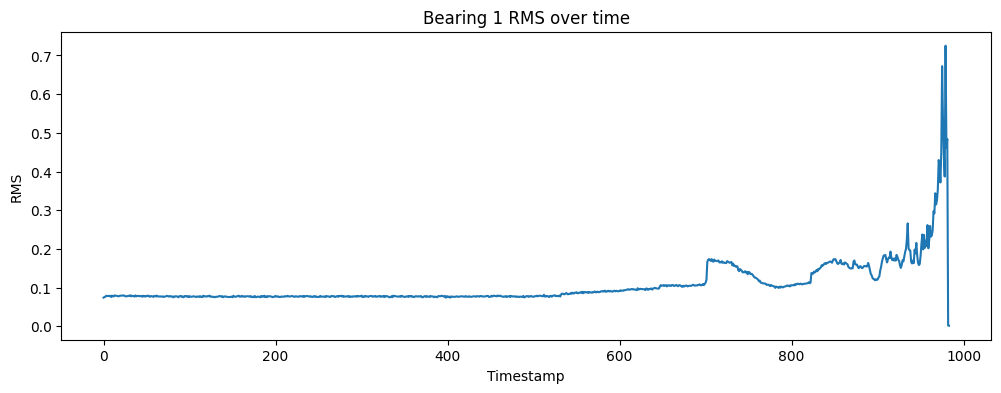

In [127]:
import matplotlib.pyplot as plt

results_df['rms1'].plot(figsize=(12, 4), title='Bearing 1 RMS over time')
plt.xlabel('Timestamp')
plt.ylabel('RMS')
plt.show()

In [128]:
#add the target variable
results_df['target'] = results_df['rms1'].shift(-1)

In [129]:
results_df[['rms1', 'target']].head()

,rms1,target
0,0.074179,0.075382
1,0.075382,0.076230
2,0.076230,0.078724
3,0.078724,0.078474
4,0.078474,0.078315


In [130]:
results_df[['rms1', 'target']].tail(10) # view tail end of dataset to see what rows should be removed

,rms1,target
974,0.447673,0.672137
975,0.672137,0.530956
976,0.530956,0.445918
977,0.445918,0.386975
978,0.386975,0.725001
979,0.725001,0.462012
980,0.462012,0.483835
981,0.483835,0.002103
982,0.002103,0.001533
983,0.001533,NaN


In [131]:
#drop last 3 rows due to drop off and NAN value
results_df = results_df.iloc[:-3]

In [132]:
results_df.shape

(981, 26)

In [133]:
results_df['time_idx'] = np.arange(len(results_df))
print(results_df.shape)

(981, 27)


In [134]:
# Cyclic Calendar Feature Encoding (Unit Circle)
#
# Calendar values like hour, day of week, and month are cyclical, which means
# the end wraps back around to the beginning (e.g. 11pm and midnight are 
# 1 hour apart, not 23 hours apart). If we feed raw integers to a model,
# it treats them as linear and has no way to know the scale wraps around.
#
# To fix this, we encode each calendar component as a (cos, sin) pair,
# which maps the value onto the unit circle (a circle with radius 1).
# Each value becomes a point on the circle, described by its x (cos) and 
# y (sin) coordinates. Values that are close in time end up close together
# numerically, even across the wrap-around boundary.
#
# The formula for any cyclic feature is:
#   sin_feature = np.sin(2 * np.pi * value / cycle_length)
#   cos_feature = np.cos(2 * np.pi * value / cycle_length)
#
# Where cycle_length is the total number of steps in one full cycle:
#   hour of day   → divide by 24
#   day of week   → divide by 7
#   day of month  → divide by 31
#   day of year   → divide by 365
#   month of year → divide by 12
#
# Two features (sin + cos) are needed per component because sin alone is
# ambiguous — for example, 2am and 10am have the same sin value. Together,
# sin and cos uniquely identify any point on the circle.


results_df['hour_sin'] = np.sin(2 * np.pi * results_df['timestamp'].dt.hour / 24)
results_df['hour_cos'] = np.cos(2 * np.pi * results_df['timestamp'].dt.hour / 24)
results_df['day_sin'] = np.sin(2 * np.pi * results_df['timestamp'].dt.dayofweek / 7)
results_df['day_cos'] = np.cos(2 * np.pi * results_df['timestamp'].dt.dayofweek / 7)
results_df['day_month_sin'] = np.sin(2 * np.pi * results_df['timestamp'].dt.day / 31)
results_df['day_month_cos'] = np.cos(2 * np.pi * results_df['timestamp'].dt.day / 31)
results_df['year_sin'] = np.sin(2 * np.pi * results_df['timestamp'].dt.day_of_year / 365)
results_df['year_cos'] = np.cos(2 * np.pi * results_df['timestamp'].dt.day_of_year / 365)
results_df['month_year_sin'] = np.sin(2 * np.pi * results_df['timestamp'].dt.month / 12)
results_df['month_year_cos'] = np.cos(2 * np.pi * results_df['timestamp'].dt.month / 12)

In [135]:
# FFT Seasonal Feature Extraction
#
# FFT (Fast Fourier Transform) is a mathematical technique that decomposes
# a signal into its frequency components by essentially detecting what
# repeating cycles (seasonality) are hidden inside the data.
#
# This is the same concept as seasonality in traditional time series analysis
# (e.g. holiday spikes in retail sales, quarterly patterns in finance), except
# FFT detects the dominant cycles automatically from the signal itself rather
# than requiring us to assume them in advance.
#
# For bearing vibration data, these cycles correspond to real physical phenomena:
#   - Ball pass frequency (how often a ball rolls over a fault)
#   - Shaft rotation frequency
#   - Bearing housing resonance frequencies
#
# Steps:
#   1. Run FFT on the rms1 signal to get the strength of every possible frequency
#   2. Convert frequencies to periods (period = 1 / frequency)
#   3. Pick the top k strongest periods (we use k=3) — these are the dominant cycles
#   4. For each detected period, encode it as a sin/cos pair across all rows
#      using the running index (time_idx) as the position in the cycle
#
# Every row gets a value for every seasonal feature — the period determines
# how quickly the sin/cos wave completes one full rotation, not which rows
# are included. No rows are left out.
#
# Formula for each detected period:
#   seasonal_sin = np.sin(2 * np.pi * time_idx / period)
#   seasonal_cos = np.cos(2 * np.pi * time_idx / period)
#
# The result is 2*k new columns (sin + cos per period) added to the dataframe,
# giving both models information about where each snapshot falls within each
# dominant cycle of the bearing's degradation signal.

# When discussing frequency, it means how often a pattern repeats.Example:
# frequency 0.125  →  period 8    (repeats every 8 snapshots)
# frequency 0.25   →  period 4    (repeats every 4 snapshots)
# frequency 0.5    →  period 2    (repeats every 2 snapshots)

signal = results_df['rms1'].values
n = len(signal)

fft_magnitudes = np.abs(fft(signal)) # Taking the absolute value converts each complex number to a single magnitude/strength for every frequency
# since the fft_magnitudes has both symmetric positive and negative values, the information is redundant
# so im only going to extract the positive values
positive_magnitudes = fft_magnitudes[:n//2]

fft_freq = fftfreq(n) # generates the list of frequencies that correspond to each position in the fft_magnitudes output.
positive_freqs = fft_freq[:n//2] # these values are also symmetric like the fft_magnitudes, so extracting only pos values

# find top 3 dominant frequency periods
k = 3

top_magnitude_indices = np.argsort(positive_magnitudes)[::-1][1:k+1] # skip index 0 (DC component)
top_periods = 1 / positive_freqs[top_magnitude_indices]


In [136]:
results_df['period1_sin'] = np.sin(2 * np.pi * results_df['time_idx'] / top_periods[0])
results_df['period1_cos'] = np.cos(2 * np.pi * results_df['time_idx'] / top_periods[0])
results_df['period2_sin'] = np.sin(2 * np.pi * results_df['time_idx'] / top_periods[1])
results_df['period2_cos'] = np.cos(2 * np.pi * results_df['time_idx'] / top_periods[1])
results_df['period3_sin'] = np.sin(2 * np.pi * results_df['time_idx'] / top_periods[2])
results_df['period3_cos'] = np.cos(2 * np.pi * results_df['time_idx'] / top_periods[2])

In [137]:
top_periods

print(top_periods)

[981.   245.25 490.5 ]


In [138]:
print(results_df.columns)
print(results_df.shape)

Index(['timestamp', 'rms1', 'peak1', 'kurtosis1', 'skew1', 'std1',
       'crest_factor1', 'rms2', 'peak2', 'kurtosis2', 'skew2', 'std2',
       'crest_factor2', 'rms3', 'peak3', 'kurtosis3', 'skew3', 'std3',
       'crest_factor3', 'rms4', 'peak4', 'kurtosis4', 'skew4', 'std4',
       'crest_factor4', 'target', 'time_idx', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'day_month_sin', 'day_month_cos', 'year_sin',
       'year_cos', 'month_year_sin', 'month_year_cos', 'period1_sin',
       'period1_cos', 'period2_sin', 'period2_cos', 'period3_sin',
       'period3_cos'],
      dtype='object')
(981, 43)


In [139]:
n = len(signal)
fftfreq(n)[:n//2]


array([0.        , 0.00101937, 0.00203874, 0.0030581 , 0.00407747,
       0.00509684, 0.00611621, 0.00713558, 0.00815494, 0.00917431,
       0.01019368, 0.01121305, 0.01223242, 0.01325178, 0.01427115,
       0.01529052, 0.01630989, 0.01732926, 0.01834862, 0.01936799,
       0.02038736, 0.02140673, 0.0224261 , 0.02344546, 0.02446483,
       0.0254842 , 0.02650357, 0.02752294, 0.0285423 , 0.02956167,
       0.03058104, 0.03160041, 0.03261978, 0.03363914, 0.03465851,
       0.03567788, 0.03669725, 0.03771662, 0.03873598, 0.03975535,
       0.04077472, 0.04179409, 0.04281346, 0.04383282, 0.04485219,
       0.04587156, 0.04689093, 0.0479103 , 0.04892966, 0.04994903,
       0.0509684 , 0.05198777, 0.05300714, 0.0540265 , 0.05504587,
       0.05606524, 0.05708461, 0.05810398, 0.05912334, 0.06014271,
       0.06116208, 0.06218145, 0.06320082, 0.06422018, 0.06523955,
       0.06625892, 0.06727829, 0.06829766, 0.06931702, 0.07033639,
       0.07135576, 0.07237513, 0.0733945 , 0.07441386, 0.07543

In [143]:
feature_columns = []

for col in results_df.columns:
    if col not in ["timestamp", "target"]:
        feature_columns.append(col)

X = results_df[feature_columns]
y = results_df["target"]

In [146]:
train_idx = int(len(results_df) *.80) # 80% of data will be training. making sure to capture FIRST 80% to prevent data leakage

train_X = X.iloc[:train_idx]
train_y = y.iloc[:train_idx]
test_X = X.iloc[train_idx:]
test_y = y.iloc[train_idx:]

print(train_X.shape, test_X.shape)

(784, 41) (197, 41)


In [173]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(train_X, train_y)
xgb_predictions = xgb_model.predict(test_X)

In [174]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

xgb_rmse = np.sqrt(mean_squared_error(test_y, xgb_predictions))
xgb_mae = mean_absolute_error(test_y, xgb_predictions)
xgb_correlation = np.corrcoef(test_y, xgb_predictions)[0,1]

print(f"XGB RMSE: {xgb_rmse:.4f}")
print(f"XGB MAE: {xgb_mae:.4f}")
print(f"XGB Correlation: {xgb_correlation:.4f}")

XGB RMSE: 0.1044
XGB MAE: 0.0570
XGB Correlation: 0.3645


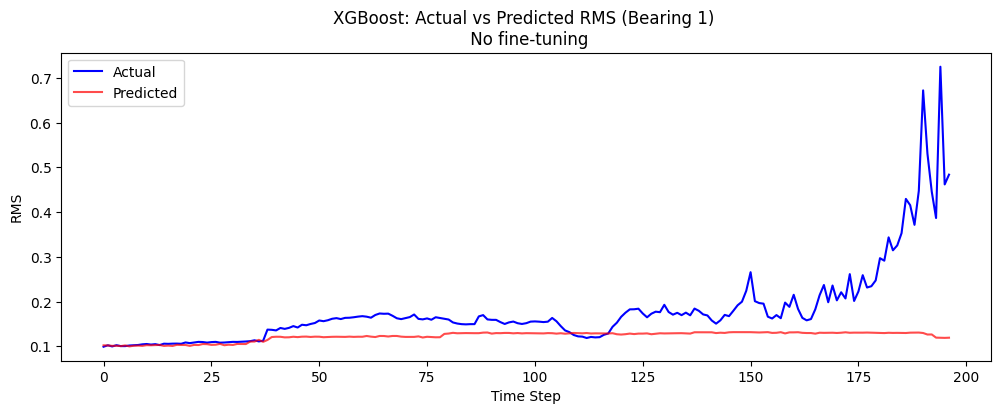

In [177]:
plt.figure(figsize=(12, 4))
plt.plot(test_y.values, label='Actual', color='blue')
plt.plot(xgb_predictions, label='Predicted', color='red', alpha=0.7)
plt.title('XGBoost: Actual vs Predicted RMS (Bearing 1) \n No fine-tuning')
plt.xlabel('Time Step')
plt.ylabel('RMS')
plt.legend()
plt.show()

In [ ]:
import os
from tabpfn_client import TabPFNRegressor, set_access_token
set_access_token(os.environ["TABPFN_ACCESS_TOKEN"])
tabpfn_model = TabPFNRegressor()
tabpfn_model.fit(train_X, train_y)
tabpfn_predictions = tabpfn_model.predict(test_X)

In [169]:
tab_rmse = np.sqrt(mean_squared_error(test_y, tabpfn_predictions))
tab_mae = mean_absolute_error(test_y, tabpfn_predictions)
tab_correlation = np.corrcoef(test_y, tabpfn_predictions)[0,1]

print(f"TabPFN RMSE: {tab_rmse:.4f}")
print(f"TabPFN MAE: {tab_mae:.4f}")
print(f"TabPFN Correlation: {tab_correlation:.4f}")

TabPFN RMSE: 0.0706
TabPFN MAE: 0.0283
TabPFN Correlation: 0.7266


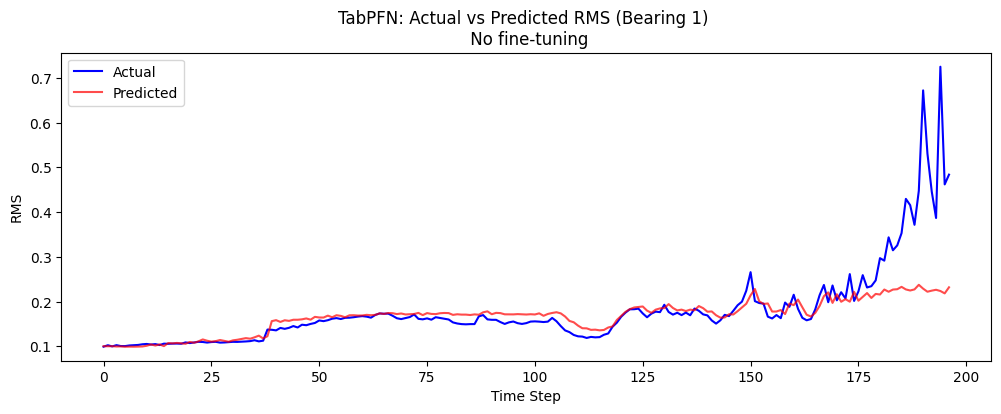

In [178]:
plt.figure(figsize=(12, 4))
plt.plot(test_y.values, label='Actual', color='blue')
plt.plot(tabpfn_predictions, label='Predicted', color='red', alpha=0.7)
plt.title('TabPFN: Actual vs Predicted RMS (Bearing 1) \n No fine-tuning')
plt.xlabel('Time Step')
plt.ylabel('RMS')
plt.legend()
plt.show()

## Baseline Model Comparison

The following results are from both models using default hyperparameters, 
trained on the same feature set (bearing statistics + calendar features + FFT seasonal features).
No hyperparameter tuning was applied at this stage.

| Model   | RMSE   | MAE    | Correlation |
|---------|--------|--------|-------------|
| XGBoost | 0.1044 | 0.0570 | 0.3645      |
| TabPFN  | 0.0706 | 0.0283 | 0.7266      |

**Key observations:**
- TabPFN outperforms XGBoost on all three metrics with zero tuning
- TabPFN's correlation (0.73) is nearly double XGBoost's (0.36), indicating it 
  better captures the bearing degradation trend
- XGBoost predicted a near-flat line, failing to track the rising RMS signal
- TabPFN successfully tracked the degradation trajectory through most of the test period

Next: hyperparameter tuning of XGBoost to see if the gap can be closed.

In [ ]:
# n_estimators — number of trees. More trees = more capacity to learn complex patterns.
#max_depth — how deep each tree can grow. Deeper trees can capture more complex relationships but risk overfitting. 
#learning_rate — how much each tree contributes to the final prediction. Lower = more conservative, needs more trees to compensate. 
#subsample — fraction of training rows used per tree. Adds randomness, helps prevent overfitting.
#colsample_bytree — fraction of features used per tree. Similar idea to subsample but for columns. 
#min_child_weight — minimum number of samples required in a leaf node. Higher values make the model more conservative. 

param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}


# time series cross validation (no shuffling). 
# divides training data into 5 sequential folds for cross validation, keeping temporal order intact
# Walk-forward validation with expanding window
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(random_state=42, 
                         device="cuda",
                         tree_method='hist')

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=35,          # 35 random combinations
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=1,         
    verbose=1
)

search.fit(train_X, train_y)

print("Best parameters:", search.best_params_)
print("Best RMSE:", -search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.3, 'colsample_bytree': 0.6}
Best RMSE: 0.010658427077637667


In [ ]:
xgb_model_tuned = XGBRegressor(subsample = 0.6,
                               n_estimators=500,
                               random_state=42,
                               min_child_weight=3,
                               max_depth=3,
                               learning_rate=.3,
                               colsample_bytree=.6)
xgb_model_tuned.fit(train_X, train_y)
xgb_predictions = xgb_model_tuned.predict(test_X)


xgb_rmse_tuned = np.sqrt(mean_squared_error(test_y, xgb_predictions))
xgb_mae_tuned = mean_absolute_error(test_y, xgb_predictions)
xgb_correlation_tuned = np.corrcoef(test_y, xgb_predictions)[0,1]

print(f"XGB RMSE Tuned: {xgb_rmse_tuned:.4f}")
print(f"XGB MAE Tuned: {xgb_mae_tuned:.4f}")
print(f"XGB Correlation Tuned: {xgb_correlation_tuned:.4f}")

XGB RMSE: 0.1017
XGB MAE: 0.0553
XGB Correlation: 0.5591


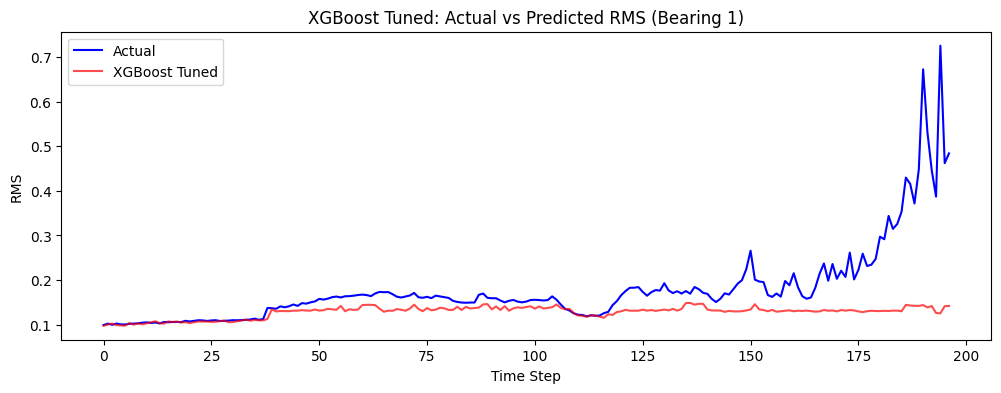

In [187]:
xgb_tuned_predictions = search.best_estimator_.predict(test_X)

plt.figure(figsize=(12, 4))
plt.plot(test_y.values, label='Actual', color='blue')
plt.plot(xgb_tuned_predictions, label='XGBoost Tuned', color='red', alpha=0.7)
plt.title('XGBoost Tuned: Actual vs Predicted RMS (Bearing 1)')
plt.xlabel('Time Step')
plt.ylabel('RMS')
plt.legend()
plt.show()

| Model          | RMSE   | MAE    | Correlation |
|----------------|--------|--------|-------------|
| XGBoost        | 0.1044 | 0.0570 | 0.3645      |
| XGBoost Tuned  | 0.1017 | 0.0553 | 0.5591      |
| TabPFN         | 0.0706 | 0.0283 | 0.7266      |

In [189]:
plot_data = {
    'Model': ["XGBoost", "XGBoost Tuned", "TabPFN"],
    'RMSE': [0.1044, 0.1017, 0.0706], 
    'MAE': [0.0570, 0.0553, 0.0283],
    'Correlation': [0.3645, 0.5591, 0.7266]
}

plot_df = pd.DataFrame(plot_data)
print(plot_df)

           Model    RMSE     MAE  Correlation
0        XGBoost  0.1044  0.0570       0.3645
1  XGBoost Tuned  0.1017  0.0553       0.5591
2         TabPFN  0.0706  0.0283       0.7266


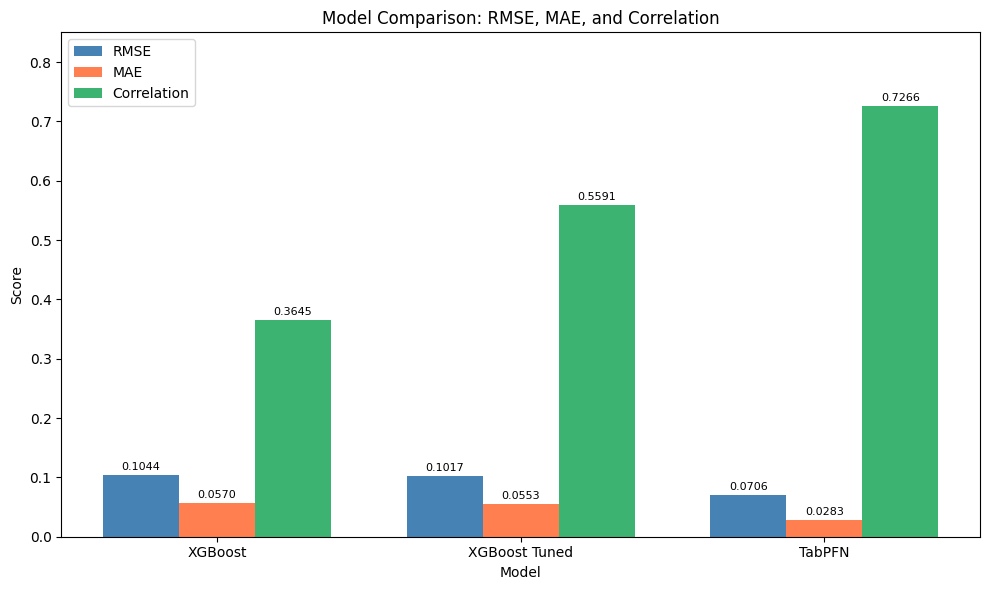

In [ ]:
models = plot_df['Model']
metrics = ['RMSE', 'MAE', 'Correlation']
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, plot_df['RMSE'], width, label='RMSE', color='steelblue')
bars2 = ax.bar(x, plot_df['MAE'], width, label='MAE', color='coral')
bars3 = ax.bar(x + width, plot_df['Correlation'], width, label='Correlation', color='mediumseagreen')

# add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: RMSE, MAE, and Correlation')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 0.85)

plt.tight_layout()
plt.show()
